In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
import seaborn as sns

sns.set()

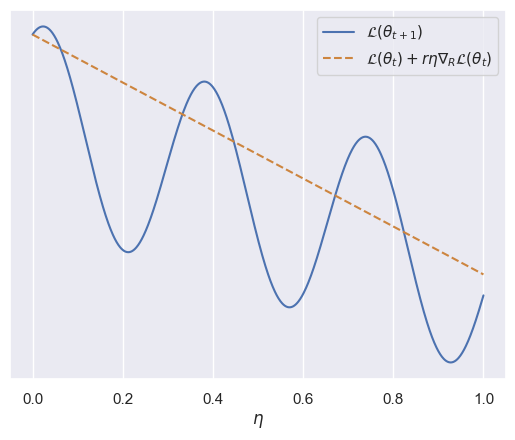

In [3]:
def loss(theta):
    return 45*jnp.cos(theta) + 4*theta

grad_loss = grad(loss)
etas = jnp.linspace(0, 1, 1000)
theta_t = 0.5
r = 0.15
grad_theta_t = grad_loss(theta_t)

plt.plot(etas, loss(theta_t + etas*grad_theta_t), label=r"$\mathcal{L}(\theta_{t+1})$")
plt.plot(etas, loss(theta_t) + r*etas*grad_theta_t*loss(theta_t), color="peru", linestyle="dashed", label=r"$\mathcal{L}(\theta_t) + r \eta \nabla_R \mathcal{L}(\theta_t)$")
plt.yticks([])
plt.xlabel(r"$\eta$")
plt.legend()
plt.savefig("armijo_cond.png")
plt.show()

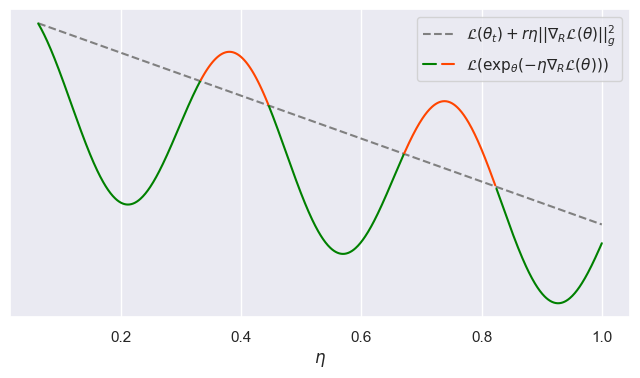

In [6]:
cond = loss(theta_t) + r*etas*grad_theta_t*loss(theta_t)
loss_vals = loss(theta_t + etas*grad_theta_t)

cond_true = loss_vals[loss_vals <= cond]
cond_true_etas = etas[loss_vals <= cond]

cond_false = loss_vals[loss_vals > cond]
cond_false_etas = etas[loss_vals > cond]

fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))
p1, = ax1.plot(etas[63:], (loss(theta_t) + r*etas*grad_theta_t*loss(theta_t))[63:], color="grey", linestyle="dashed")
p2, = ax1.plot(cond_true_etas[1:271], cond_true[1:271], color="green")
plt.plot(cond_true_etas[271:496], cond_true[271:496], color="green")
plt.plot(cond_true_etas[497:], cond_true[497:], color="green")
#plt.plot(cond_false_etas[1:62], cond_false[1:62], color="orangered")
p3, = ax1.plot(cond_false_etas[62:175], cond_false[62:175], color="orangered")
plt.plot(cond_false_etas[175:], cond_false[175:], color="orangered")

l = ax1.legend([p1, (p2, p3)], [r"$\mathcal{L}(\theta_t) + r \eta || \nabla_R \mathcal{L}(\theta) ||_g^2$", r"$\mathcal{L}(\text{exp}_\theta (- \eta \nabla_R \mathcal{L}(\theta) ))$"], handler_map={tuple: HandlerTuple(ndivide=None)})
plt.yticks([])
plt.xlabel(r"$\eta$")
plt.savefig("armijo_cond_colored.png", dpi=500, bbox_inches = "tight")
plt.show()